# 손 X-ray 골연령 예측 — **InceptionV3 + Bilinear Pooling** (논문 최종 모델 재현)

> Zhang, Wu, Zhou & Li, *Uncertainty-aware multi-stream deep learning for pediatric bone age assessment* (JKSU-CIS, 2026) — **최종 채택 모델(MAE 4.10개월)** 을 §3.7·§4 그대로 구현.

## 논문 대비 구현 상태
- **아키텍처**: 식 30~36 그대로 (InceptionV3 top 제거 → 1×1 conv 2048→512→128 → bilinear pooling(16,384) → 성별 임베딩 16 concat → 선형회귀 1). 정규화(sqrt+ℓ2)는 논문대로 생략.
- **전처리**: `CROP_MODE`로 선택. 기본값 **`"advanced"`** 순서는 **[전처리 노트북 파이프라인: 흑백+손크롭+리사이즈] → 히스토그램 평활화 → 모델**. 즉 최종모델의 "흑백+자동크롭+리사이즈"를 전처리 노트북(CLAHE·마커소거·손 실루엣 크롭)으로 대체한 뒤, 마지막에 `equalizeHist`를 적용. (`"paper"`=표8 3단계, `"plate"`=개선 실험용)
- **평가지표**: 검증·테스트 모두 **MAE와 RMSE**(개월)를 함께 출력.
- **데이터**: RSNA 공식 분할 사용 — **train(학습) · val(검증·best 선택) · test(최종 평가)**. 학습 전 이상 이미지(`EXCLUDE_IDS`)는 제외.
- **재현 스위치**(PART 0의 `0-3` 셀): `CROP_MODE="paper"`, `USE_AUG=False` 가 **논문 재현 기준선**입니다. 개선 실험은 기준선 MAE를 확보한 뒤 **한 번에 하나씩만** 바꿔 델타를 기록하세요.
- **논문 미명시 항목(가정)**: 타깃 z-정규화 + L1 손실, Adam(1e-4)/ReduceLROnPlateau, 입력 480×480(§3.2 InceptionV3 기준). 모두 개월 단위로 환산해 평가하므로 MAE 해석은 논문과 동일합니다.

## 🔧 실행 가이드 (단계별로 저장·로드되므로 필요한 파트만 돌릴 수 있음)

| 상황 | 실행할 파트 |
|---|---|
| **처음부터 전체** | PART 0 → 1 → 2 → 3 → 4 |
| **하이퍼파라미터만 바꿔 재학습** | PART 0 → 1(캐시 있으면 즉시 스킵) → **PART 2에서 값 수정** → 3 → 4 |
| **전처리(크롭/해상도)를 바꿈** | PART 0의 `0-3`에서 `CROP_MODE`/`IMG_SIZE` 수정 → PART 1 (설정별로 캐시 폴더가 분리되어 자동 재생성) → 2 → 3 |
| **학습 중단 후 이어서** | PART 0 → 1 → PART 2(`RESUME=True`) → 3 |
| **저장된 모델로 평가/추론만** | PART 0 → 1 → **PART 4** (단일 이미지 추론은 `best.pt` + 이미지 1장이면 충분) |

**저장물(모두 `BASE_DIR` 아래)**
- `cache_preprocessed/{크롭모드}_{해상도}/` : 전처리 이미지 + `_DONE.json` 완료표식 → 다음 실행 때 자동 스킵
- `checkpoints/best.pt` : **검증 MAE 최저 순간 즉시 저장** (모델+정규화상수+구조+전처리설정 → 자체 완결)
- `checkpoints/last.pt` : 매 에폭 저장 (옵티마이저·스케줄러 포함 → **중단 재개**용)
- `checkpoints/history.json` : 학습 곡선 데이터


---
# PART 0 · 공통 셋업  *(항상 먼저 실행 — 전부 정의/로드, 무거운 연산 없음)*

### 0-1. 환경 확인

In [1]:
import os, sys, json, math, random, time
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms
from torchvision.models import inception_v3, Inception_V3_Weights
from torchvision.models.feature_extraction import create_feature_extractor
from tqdm.auto import tqdm

print("Python     :", sys.version.split()[0])
print("PyTorch    :", torch.__version__)
print("torchvision:", torchvision.__version__)
print("CUDA avail :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU        :", torch.cuda.get_device_name(0), "| CUDA", torch.version.cuda)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device     :", device)

# [주의] RTX 5060(Blackwell, sm_120)은 최신 PyTorch 필요.
# CUDA=False 이거나 'no kernel image' 오류 시 CUDA 12.8+ 빌드 설치:
#   pip install --pre torch torchvision --index-url https://download.pytorch.org/whl/nightly/cu128

Python     : 3.11.9
PyTorch    : 2.12.0.dev20260408+cu128
torchvision: 0.27.0.dev20260407+cu128
CUDA avail : True
GPU        : NVIDIA GeForce RTX 5060 Laptop GPU | CUDA 12.8
device     : cuda


### 0-2. 시드 & 한글 경로 로더

In [2]:
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

def imread_kr(path, flags=cv2.IMREAD_GRAYSCALE):
    '''한글/유니코드 경로에서도 동작하는 이미지 로드. 실패 시 None.'''
    try:
        data = np.fromfile(str(path), dtype=np.uint8)
        return cv2.imdecode(data, flags)
    except Exception:
        return None

def imwrite_kr(path, img):
    '''한글/유니코드 경로에도 저장 가능한 이미지 쓰기.'''
    path = str(path); ext = os.path.splitext(path)[1] or ".png"
    ok, buf = cv2.imencode(ext, img)
    if ok: buf.tofile(path)
    return ok

### 0-3. 경로 설정 & 전처리 파라미터
**`BASE_DIR` 한 줄만** 본인 경로로 수정하세요. `IMG_SIZE`는 전처리(캐시)와 직결되므로 여기 둡니다 — 바꾸면 캐시를 다시 만들어야 합니다.

In [3]:
# ── 경로: 여기만 수정 ───────────────────────────────────────────────
BASE_DIR = Path(r"C:\Users\Win11Pro\Desktop\뼈데이터")   # ← 수정

TRAIN_IMG_DIR = BASE_DIR / "Bone+Age+Training+Set" / "boneage-training-dataset"
TRAIN_CSV     = BASE_DIR / "Bone+Age+Training+Set+Annotations" / "train.csv"
VAL_IMG_DIR   = BASE_DIR / "Bone+Age+Validation+Set" / "Bone Age Validation Set" / "boneage-validation-dataset-1"
VAL_CSV       = BASE_DIR / "Bone+Age+Validation+Set" / "Bone Age Validation Set" / "Validation Dataset.csv"

# ── test 세트 (★ 실제 폴더/CSV 이름에 맞게 수정) ──────────────────────
TEST_IMG_DIR  = BASE_DIR / "Bone+Age+Test+Set" / "Test+Set+Images"
TEST_CSV      = BASE_DIR / "Bone+Age+Test+Set" / "Bone age ground truth.csv"

# ── 재현 스위치 (전처리·증강) ──────────────────────────────────────
IMG_SIZE  = 512          # 논문 InceptionV3 단일스트림 입력
CROP_MODE = "advanced"   # "paper"   : 논문 표8식 단순 bbox 크롭 (재현 기준선)
                         # "plate"   : 2단계 크롭(플레이트+문자마커 제거) — 개선 실험용
                         # "advanced": 전처리 노트북(bone_age_preprocess) 파이프라인 이식본.
                         #             CLAHE→마커소거→손실루엣 크롭→밝기정합(리사이즈 전)→정사각 리사이즈
USE_AUG   = False        # 논문 미언급. 재현 기준선은 False, 개선 실험에서만 True

# ── 마지막 히스토그램 평활화 방식 스위치 ───────────────────────────
#   "he"    : 전역 히스토그램 평활화 cv2.equalizeHist (원본 최종모델)
#   "clahe" : CLAHE 로 마지막 평활화
#   "none"  : 마지막 평활화 없음 (전처리 노트북 파이프라인까지만)
EQUALIZE  = "none"

# 캐시는 (크롭모드 × 해상도 × 평활화)별로 분리 저장 → 설정을 바꿔도 서로 덮어쓰지 않음
CACHE_DIR = BASE_DIR / "cache_preprocessed_1" / f"{CROP_MODE}_{IMG_SIZE}_{EQUALIZE}"
CKPT_DIR  = BASE_DIR / "checkpoints_1"
for d in (CACHE_DIR, CACHE_DIR/"train", CACHE_DIR/"val", CACHE_DIR/"test", CKPT_DIR):
    d.mkdir(parents=True, exist_ok=True)

BEST_CKPT    = CKPT_DIR / "best.pt"          # 배포/추론용(가벼움, 자체완결)
LAST_CKPT    = CKPT_DIR / "last.pt"          # 재개용(옵티마이저 포함)
HISTORY_JSON = CKPT_DIR / "history.json"
DONE_MARKER  = CACHE_DIR / "_DONE.json"

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ── 모델 학습/평가 전 제외할 이상 이미지 (파일명 stem) ──
EXCLUDE_IDS = {"1521","1607","1779","2256","2414","2823","3883","3885",
               "3899","3905","3931","3964","3999","4004","4230"}
print(f"BASE_DIR : {BASE_DIR}")
print(f"IMG_SIZE : {IMG_SIZE} | CROP_MODE: {CROP_MODE} | USE_AUG: {USE_AUG} | EQUALIZE: {EQUALIZE}")
print(f"CACHE    : {CACHE_DIR}")


BASE_DIR : C:\Users\Win11Pro\Desktop\뼈데이터
IMG_SIZE : 512 | CROP_MODE: advanced | USE_AUG: False | EQUALIZE: none
CACHE    : C:\Users\Win11Pro\Desktop\뼈데이터\cache_preprocessed_1\advanced_512_none


### 0-4. 라벨 로드 (CSV) & 타깃 통계

In [4]:
def load_labels(csv_path, img_dir):
    '''id/boneage/male 컬럼을 유연하게 탐지해 표준 DataFrame으로 반환.'''
    df = pd.read_csv(csv_path)
    cols = {c.lower().strip(): c for c in df.columns}
    def pick(keys):
        for k in keys:
            for lc, orig in cols.items():
                if k in lc: return orig
        return None
    id_col  = pick(["id", "case", "image"]) or df.columns[0]
    age_col = pick(["boneage", "bone age", "age"])
    sex_col = pick(["male", "sex", "gender"])
    assert age_col and sex_col, f"컬럼 탐지 실패: {list(df.columns)}"
    out = pd.DataFrame()
    out["id"]      = df[id_col].astype(str).str.replace(".png","",regex=False).str.strip()
    out["boneage"] = pd.to_numeric(df[age_col], errors="coerce")
    s = df[sex_col]
    if s.dtype == bool:
        male = s.astype(int)
    else:
        sv = s.astype(str).str.lower().str.strip()
        male = sv.map({"true":1,"false":0,"m":1,"f":0,"male":1,"female":0,"1":1,"0":0})
        if male.isna().any(): male = pd.to_numeric(s, errors="coerce")
    out["male"] = male.astype(float)
    out["path"] = out["id"].apply(lambda i: str(Path(img_dir)/f"{i}.png"))
    return out.dropna(subset=["boneage","male"]).reset_index(drop=True)

train_df = load_labels(TRAIN_CSV, TRAIN_IMG_DIR)
val_df   = load_labels(VAL_CSV,   VAL_IMG_DIR)

# test 세트 로드 (경로가 있으면). 없으면 빈 DF로 두고 안내만.
HAS_TEST = TEST_CSV.exists() and TEST_IMG_DIR.exists()
if HAS_TEST:
    test_df = load_labels(TEST_CSV, TEST_IMG_DIR)
else:
    test_df = pd.DataFrame(columns=["id","boneage","male","path"])
    print("⚠ test 세트를 찾지 못했습니다 → 셀 0-3의 TEST_IMG_DIR / TEST_CSV 경로를 확인하세요.")
    print("   IMG:", TEST_IMG_DIR); print("   CSV:", TEST_CSV)

# ── 이상 이미지 제외 (모델 학습/평가 전) ──
def drop_excluded(df, name):
    before = len(df)
    df = df[~df["id"].isin(EXCLUDE_IDS)].reset_index(drop=True)
    if before - len(df):
        print(f"  · {name}: 이상 이미지 {before-len(df)}장 제외")
    return df
train_df = drop_excluded(train_df, "train")
val_df   = drop_excluded(val_df,   "val")
test_df  = drop_excluded(test_df,  "test")

AGE_MEAN = float(train_df.boneage.mean())     # 회귀 안정화용(가정): 학습셋 통계
AGE_STD  = float(train_df.boneage.std())
print(f"학습 {len(train_df):,} · 검증 {len(val_df):,} · 테스트 {len(test_df):,} | 나이 {AGE_MEAN:.2f}±{AGE_STD:.2f} | 남 {train_df.male.mean():.1%}")

  · train: 이상 이미지 15장 제외
학습 12,596 · 검증 1,425 · 테스트 200 | 나이 127.31±41.17 | 남 54.2%


### 0-5. 전처리 함수 (표준 3단계 · 논문 표 8)
① 흑백 + **자동 손 크롭** → ② 리사이즈 → ③ 히스토그램 평활화.

**크롭 모드 2종** (`CROP_MODE`, 0-3 셀에서 설정):

| 모드 | 내용 | 용도 |
|---|---|---|
| **`"paper"` (기본)** | 논문 표8의 "automatic bounding box cropping" 그대로 — Otsu → 최대 blob의 bbox. 형태학 커널을 이미지 크기에 비례시켜 해상도가 달라도 동작 | **재현 기준선** |
| `"plate"` | 밝은 촬영 플레이트를 먼저 찾고, 판 안에서 연결요소 필터로 프레임·문자마커(L/CLT/JCO 등) 제거 | 개선 실험 (전수 시각 검증 후에만) |

> 여기 Otsu는 **손/배경 분리(크롭용)** 이며, Multi-stream의 *뼈 마스크 뷰*와는 다릅니다 — 최종 모델은 CLAHE·뼈마스크를 쓰지 않습니다.


In [5]:
def crop_hand_paper(gray, pad_ratio=0.03):
    """(A) 논문 표8식 크롭: Otsu -> 최대 blob의 bounding box.  ★기본값
       형태학 커널을 이미지 크기에 비례시켜 원본 해상도가 달라도 동작합니다."""
    H, W = gray.shape
    blur = cv2.GaussianBlur(gray, (7, 7), 0)
    _, m = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    k  = max(3, int(min(H, W) * 0.02) | 1)          # 짧은 변의 2%, 홀수
    ks = max(3, (k // 3) | 1)
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN,  np.ones((ks, ks), np.uint8))  # 잡티 제거
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, np.ones((k, k),  np.uint8))   # 손을 한 덩어리로
    cnts, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return gray
    x, y, w, h = cv2.boundingRect(max(cnts, key=cv2.contourArea))
    px, py = int(w * pad_ratio), int(h * pad_ratio)
    roi = gray[max(0, y-py):min(H, y+h+py), max(0, x-px):min(W, x+w+px)]
    return roi if roi.size else gray


def crop_hand_roi(gray, pad_ratio=0.03):
    """(B) 2단계 크롭: (1) 촬영 플레이트 검출 -> (2) 판 안에서 손만 분리.
       프레임/글자마커(L/CLT/JCO 등)는 연결요소 필터로 제거됩니다.
       [주의] 논문에 없는 로직입니다 — 전수 시각 검증 전에는 기준선으로 쓰지 마세요."""
    H, W = gray.shape
    # (1) 밝은 촬영 플레이트 검출 -> 검정 배경 제거
    _, lit = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    lit = cv2.morphologyEx(lit, cv2.MORPH_OPEN, np.ones((15, 15), np.uint8))
    cnts, _ = cv2.findContours(lit, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    g_in = gray
    if cnts:
        px, py, pw, ph = cv2.boundingRect(max(cnts, key=cv2.contourArea))
        if pw * ph > 0.15 * H * W:                 # 판이 화면의 상당 부분일 때만 적용
            g_in = gray[py:py+ph, px:px+pw]
    Hi, Wi = g_in.shape

    # (2) 판 내부에서 밝은 손 분리
    blur = cv2.GaussianBlur(g_in, (7, 7), 0)
    _, hand = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    hand = cv2.morphologyEx(hand, cv2.MORPH_OPEN,  np.ones((5, 5),   np.uint8))
    hand = cv2.morphologyEx(hand, cv2.MORPH_CLOSE, np.ones((15, 15), np.uint8))

    n, _, stats, _ = cv2.connectedComponentsWithStats(hand, 8)
    best_i, best_area = -1, 0
    for i in range(1, n):
        x, y, w, h, area = stats[i]
        if w > 0.97 * Wi and h > 0.97 * Hi:        # 프레임/판 전체 -> 제외
            continue
        if area < 0.02 * Hi * Wi:                  # 글자마커/잡티 -> 제외
            continue
        if area > best_area:
            best_area, best_i = area, i
    if best_i < 0:
        return g_in
    x, y, w, h, _ = stats[best_i]
    px_, py_ = int(w * pad_ratio), int(h * pad_ratio)
    roi = g_in[max(0, y-py_):min(Hi, y+h+py_), max(0, x-px_):min(Wi, x+w+px_)]
    return roi if roi.size else g_in


CROP_FN = {"paper": crop_hand_paper, "plate": crop_hand_roi}

# ─────────────────────────────────────────────────────────────────────
# (C) "advanced" 크롭 = 전처리 노트북(bone_age_preprocess) 파이프라인 이식본.
#     [흑백 + 자동 손 크롭 + 리사이즈]를 담당 → 최종모델의 동일 단계를 대체.
#     CLAHE 대비향상 → 손 마스크 → 마커 소거 → 손 실루엣 → bbox 크롭 → 정사각 리사이즈.
#     ※ 히스토그램 평활화(equalizeHist)는 이 파이프라인 '뒤'에 preprocess()에서 적용합니다.
#       (순서: 파이프라인(크롭+리사이즈) → 히스토그램 평활화 → 모델)
# ─────────────────────────────────────────────────────────────────────
ADV_CLAHE_CLIP, ADV_CLAHE_TILE = 2.0, 8
ADV_PAD_FRAC        = 0.08
ADV_MIN_AREA_FRAC   = 0.05
ADV_MAX_AREA_FRAC   = 0.95
ADV_HAND_EXTENT_LO  = 0.30
ADV_HAND_EXTENT_HI  = 0.75
ADV_PLATE_EXTENT_TH = 0.85
ADV_MARKER_BRIGHT_TH= 200
ADV_MARKER_MAX_AREA = 4000
ADV_BG_MODE         = "keep"    # "keep"=배경 유지 | "mask"=실루엣 밖 0
ADV_SKIN_DELTA      = 12
ADV_SILH_DILATE     = 7
_adv_clahe = cv2.createCLAHE(clipLimit=ADV_CLAHE_CLIP, tileGridSize=(ADV_CLAHE_TILE, ADV_CLAHE_TILE))

def _adv_enhance(img):
    return _adv_clahe.apply(img)

def _adv_hand_mask(img):
    blur = cv2.GaussianBlur(img, (5, 5), 0)
    _, th = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    th = cv2.morphologyEx(th, cv2.MORPH_OPEN,  np.ones((5, 5),  np.uint8))
    th = cv2.morphologyEx(th, cv2.MORPH_CLOSE, np.ones((25, 25), np.uint8))
    return th

def _adv_select_hand(mask):
    n, lbl, stats, _ = cv2.connectedComponentsWithStats(mask, 8)
    if n <= 1: return None
    total = mask.size; comps = []
    for idx in range(1, n):
        x, y, w, h, area = stats[idx]
        comps.append((idx, area, area / max(w * h, 1)))
    comps.sort(key=lambda c: c[1], reverse=True)
    hand_like = [c for c in comps if ADV_HAND_EXTENT_LO <= c[2] <= ADV_HAND_EXTENT_HI
                 and c[1] >= ADV_MIN_AREA_FRAC * total]
    if hand_like:
        idx = hand_like[0][0]
    else:
        non_plate = [c for c in comps if c[2] < ADV_PLATE_EXTENT_TH]
        idx = non_plate[0][0] if non_plate else comps[0][0]
    hand = np.where(lbl == idx, 255, 0).astype(np.uint8)
    return cv2.morphologyEx(hand, cv2.MORPH_CLOSE, np.ones((15, 15), np.uint8))

def _adv_remove_markers(img, hand):
    _, bright = cv2.threshold(img, ADV_MARKER_BRIGHT_TH, 255, cv2.THRESH_BINARY)
    outside = cv2.bitwise_and(bright, cv2.bitwise_not(hand))
    n, lbl, stats, _ = cv2.connectedComponentsWithStats(outside, 8)
    marker = np.zeros_like(img); removed = 0
    for idx in range(1, n):
        if stats[idx, cv2.CC_STAT_AREA] <= ADV_MARKER_MAX_AREA:
            marker[lbl == idx] = 255; removed += 1
    if removed:
        marker = cv2.dilate(marker, np.ones((5, 5), np.uint8))
        bg_px = img[hand == 0]; bg = int(np.median(bg_px)) if bg_px.size else 0
        img = img.copy(); img[marker == 255] = bg
    return img, removed

def _adv_fill_holes(mask):
    ff = mask.copy(); h, w = mask.shape
    m2 = np.zeros((h + 2, w + 2), np.uint8)
    cv2.floodFill(ff, m2, (0, 0), 255)
    return cv2.bitwise_or(mask, cv2.bitwise_not(ff))

def _adv_silhouette(img, seed):
    bg_px = img[seed == 0]; bg = int(np.median(bg_px)) if bg_px.size else 0
    thr = max(bg + ADV_SKIN_DELTA, 1)
    fg = np.where(img > thr, 255, 0).astype(np.uint8)
    fg = cv2.morphologyEx(fg, cv2.MORPH_CLOSE, np.ones((15, 15), np.uint8))
    n, lbl, _, _ = cv2.connectedComponentsWithStats(fg, 8)
    keep = np.zeros_like(fg)
    for L in np.unique(lbl[seed > 0]):
        if L != 0: keep[lbl == L] = 255
    keep = _adv_fill_holes(keep)
    if ADV_SILH_DILATE > 0:
        keep = cv2.dilate(keep, np.ones((ADV_SILH_DILATE, ADV_SILH_DILATE), np.uint8))
    return keep

def _adv_square(img, size):
    h, w = img.shape; ss = max(h, w)
    canvas = np.zeros((ss, ss), np.uint8)
    oy, ox = (ss - h) // 2, (ss - w) // 2
    canvas[oy:oy + h, ox:ox + w] = img
    return cv2.resize(canvas, (size, size), interpolation=cv2.INTER_AREA)

def _adv_crop(img, silh):
    ys, xs = np.where(silh > 0)
    if ys.size == 0: return img
    y0, y1, x0, x1 = ys.min(), ys.max(), xs.min(), xs.max()
    H, W = img.shape
    ph, pw = int((y1 - y0) * ADV_PAD_FRAC), int((x1 - x0) * ADV_PAD_FRAC)
    y0, y1 = max(0, y0 - ph), min(H, y1 + ph + 1)
    x0, x1 = max(0, x0 - pw), min(W, x1 + pw + 1)
    out = img.copy()
    if ADV_BG_MODE == "mask":
        out[silh == 0] = 0
    return out[y0:y1, x0:x1]

def preprocess_advanced(gray, size):
    """전처리 노트북 파이프라인 = [흑백 + 자동 손 크롭 + 정사각 리사이즈]까지만 수행.
       히스토그램 평활화는 하지 않는다(뒤 단계 preprocess에서 적용). 검출 실패 시 rescue."""
    enh  = _adv_enhance(gray)
    hand = _adv_select_hand(_adv_hand_mask(enh))
    if hand is None:
        return _adv_square(enh, size)                                  # rescue: 원본 정사각 리사이즈
    enh, _ = _adv_remove_markers(enh, hand)                            # 크롭 전 마커 제거
    area_frac = float((hand > 0).sum()) / hand.size
    if not (ADV_MIN_AREA_FRAC <= area_frac <= ADV_MAX_AREA_FRAC):
        return _adv_square(enh, size)                                  # rescue
    silh = _adv_silhouette(enh, hand)
    roi  = _adv_crop(enh, silh)                                        # bbox 크롭
    return _adv_square(roi, size)                                      # 정사각 리사이즈 (여기까지가 파이프라인)



# ── 마지막 히스토그램 평활화 (EQUALIZE 스위치로 선택) ──────────────────
FINAL_CLAHE_CLIP, FINAL_CLAHE_TILE = 2.0, 8        # "clahe" 모드일 때 사용
_final_clahe = cv2.createCLAHE(clipLimit=FINAL_CLAHE_CLIP,
                               tileGridSize=(FINAL_CLAHE_TILE, FINAL_CLAHE_TILE))

def _final_equalize(img, method):
    """마지막 평활화 단계. 방식은 method(he/clahe/none)로 결정.
       - "he"    : 전역 히스토그램 평활화 (cv2.equalizeHist)
       - "clahe" : 국소 대비제한 평활화 (CLAHE, tile 단위)
       - "none"  : 평활화 없음 (입력 그대로 반환)"""
    if method == "he":    return cv2.equalizeHist(img)
    if method == "clahe": return _final_clahe.apply(img)
    if method == "none":  return img
    raise ValueError(f"알 수 없는 EQUALIZE 값: {method!r} (he/clahe/none 중 하나)")

def preprocess(gray, size=None, mode=None, equalize=None):
    """size x size uint8 생성. 크롭+리사이즈 후 마지막에 _final_equalize 적용.
       - mode="paper"/"plate": 흑백+bbox 크롭 -> 리사이즈 -> 마지막 평활화
       - mode="advanced"     : [전처리 노트북 파이프라인: 흑백+손크롭+리사이즈] -> 마지막 평활화
       마지막 평활화 방식은 equalize(기본=전역 EQUALIZE, he/clahe/none)로 결정."""
    size = size or IMG_SIZE
    mode = mode or CROP_MODE
    equalize = equalize or EQUALIZE
    if mode == "advanced":
        roi_resized = preprocess_advanced(gray, size)                      # (1)(2) 파이프라인: 크롭+리사이즈
        return _final_equalize(roi_resized, equalize)                      # (3) 마지막 평활화
    roi     = CROP_FN[mode](gray)                                          # (1) 크롭
    resized = cv2.resize(roi, (size, size), interpolation=cv2.INTER_AREA)  # (2) 리사이즈
    return _final_equalize(resized, equalize)                              # (3) 마지막 평활화

print("전처리 준비 완료 | CROP_MODE =", CROP_MODE, "| EQUALIZE =", EQUALIZE)


전처리 준비 완료 | CROP_MODE = advanced | EQUALIZE = none


### 0-6. Dataset · Transform · 모델 · 헬퍼 정의

In [6]:
# 증강은 논문에 언급이 없습니다 -> 재현 기준선(USE_AUG=False)은 정규화만 수행.
_aug = [transforms.RandomRotation(15),
        transforms.RandomAffine(0, translate=(0.05, 0.05), scale=(0.95, 1.05))]

train_tf = transforms.Compose(
    [transforms.ToPILImage()] + (_aug if USE_AUG else []) +
    [transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]
)
eval_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
print("train 증강:", "ON (rotation 15도 + affine)" if USE_AUG else "OFF (논문 재현 기준선)")

class BoneAgeDataset(Dataset):
    def __init__(self, df, split, tf):
        self.df, self.split, self.tf = df.reset_index(drop=True), split, tf
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        r = self.df.iloc[i]
        g = imread_kr(CACHE_DIR/self.split/f"{r['id']}.png", cv2.IMREAD_GRAYSCALE)
        x = self.tf(np.stack([g, g, g], -1))                    # 흑백 -> 3채널
        gender  = torch.tensor([r["male"]], dtype=torch.float32)
        y_norm  = torch.tensor([(r["boneage"]-AGE_MEAN)/AGE_STD], dtype=torch.float32)
        y_month = torch.tensor([r["boneage"]], dtype=torch.float32)
        return x, gender, y_norm, y_month


train 증강: OFF (논문 재현 기준선)


In [7]:
class InceptionV3Bilinear(nn.Module):
    """InceptionV3(ImageNet) + 순수 1x1 채널축소(2048->512->128, 식31)
       + Bilinear 풀링(식32~33) + 성별 임베딩 k=16(식34) + 선형회귀(식36).
       논문 3.7절 식 30~36 그대로."""
    def __init__(self, reduce1=512, reduce2=128, gender_dim=16,
                 pretrained=True, freeze=False, bilinear_norm=False):
        super().__init__()
        self.bilinear_norm = bilinear_norm
        weights = Inception_V3_Weights.IMAGENET1K_V1 if pretrained else None
        net = inception_v3(weights=weights, aux_logits=True)
        net.transform_input = False
        # classification top 제거: Mixed_7c 출력(2048ch)까지만 사용
        self.backbone = create_feature_extractor(net, return_nodes={"Mixed_7c": "feat"})
        if freeze:
            for p in self.backbone.parameters(): p.requires_grad = False
        # 식 31: F1 = Conv1x1(F), F2 = Conv1x1(F1) — 논문 그대로 순수 1x1 (BN/ReLU 없음)
        self.reduce = nn.Sequential(
            nn.Conv2d(2048, reduce1, 1),    # 2048 -> 512
            nn.Conv2d(reduce1, reduce2, 1), # 512  -> 128
        )
        self.gender_fc = nn.Linear(1, gender_dim)                       # 식 34
        self.regressor = nn.Linear(reduce2*reduce2 + gender_dim, 1)     # 식 35~36

    def bilinear_pool(self, f2):
        """B = X^T X / (h*w) 후 flatten -> 128^2 = 16,384 (식 32~33).
           외적은 값을 제곱하므로 AMP(fp16)에서 오버플로/정밀도 손실 위험이 있습니다.
           -> 이 구간만 autocast를 끄고 fp32로 계산합니다."""
        with torch.autocast(device_type="cuda", enabled=False):
            f2 = f2.float()
            B, C, H, W = f2.shape
            X = f2.view(B, C, H*W)
            z = torch.bmm(X, X.transpose(1, 2)).view(B, C*C) / (H*W)
            if self.bilinear_norm:                       # 논문 최종 모델은 생략(<=0.02개월)
                z = torch.sign(z) * torch.sqrt(torch.abs(z) + 1e-8)
                z = F.normalize(z, dim=1)
        return z

    def forward(self, x, gender):
        f2 = self.reduce(self.backbone(x)["feat"])
        z  = self.bilinear_pool(f2)                                   # fp32
        e  = self.gender_fc(gender).float()
        u  = torch.cat([z, e], dim=1)                                 # 식 35
        return self.regressor(u).squeeze(1)                           # 식 36


In [8]:
def build_model(arch, pretrained=False, freeze=False):
    return InceptionV3Bilinear(reduce1=arch["REDUCE_1"], reduce2=arch["REDUCE_2"],
        gender_dim=arch["GENDER_EMB_DIM"], pretrained=pretrained, freeze=freeze,
        bilinear_norm=arch["BILINEAR_NORM"]).to(device)

def mae_months(pred_norm, y_month, mean, std):
    pm = pred_norm.detach().float().cpu() * std + mean
    return (pm - y_month.cpu().squeeze(1)).abs().sum().item()

@torch.no_grad()
def evaluate(model, loader, mean, std, use_amp=True):
    model.eval(); tot, n = 0.0, 0
    for x, g, yn, ym in loader:
        x, g = x.to(device), g.to(device)
        with torch.amp.autocast("cuda", enabled=use_amp):
            pred = model(x, g)
        tot += mae_months(pred, ym, mean, std); n += x.size(0)
    return tot / n

def save_checkpoint(path, model, arch, mean, std, optimizer=None, scheduler=None,
                    scaler=None, epoch=None, best_val=None, history=None, no_improve=None):
    ck = {"model": model.state_dict(), "arch": arch, "age_mean": mean, "age_std": std}
    if optimizer  is not None: ck["optimizer"]  = optimizer.state_dict()
    if scheduler  is not None: ck["scheduler"]  = scheduler.state_dict()
    if scaler     is not None: ck["scaler"]     = scaler.state_dict()
    if epoch      is not None: ck["epoch"]      = epoch
    if best_val   is not None: ck["best_val"]   = best_val
    if history    is not None: ck["history"]    = history
    if no_improve is not None: ck["no_improve"] = no_improve   # 조기종료 카운터(재개용)
    torch.save(ck, path)

print("정의 완료: Dataset · InceptionV3Bilinear · build_model · evaluate · save_checkpoint")

정의 완료: Dataset · InceptionV3Bilinear · build_model · evaluate · save_checkpoint


---
# PART 1 · 전처리 → 캐시 저장  *(1회만; 완료 표식 있으면 자동 스킵)*

In [9]:
FORCE_REBUILD = False   # 전처리를 강제로 다시 만들려면 True

def cache_is_valid():
    if FORCE_REBUILD or not DONE_MARKER.exists(): return False
    info = json.load(open(DONE_MARKER, encoding="utf-8"))
    ok = (info.get("img_size") == IMG_SIZE and info.get("crop_mode") == CROP_MODE
          and info.get("equalize") == EQUALIZE)
    if ok and len(test_df) and not (CACHE_DIR/"test"/f"{test_df.iloc[0]['id']}.png").exists():
        return False   # test가 추가됐는데 캐시에 없으면 재빌드
    return ok

def build_cache(df, split):
    out_dir = CACHE_DIR / split; made = skipped = failed = 0
    for _, r in tqdm(df.iterrows(), total=len(df), desc=f"cache/{split}"):
        dst = out_dir / f"{r['id']}.png"
        if dst.exists() and not FORCE_REBUILD: skipped += 1; continue
        g = imread_kr(r["path"], cv2.IMREAD_GRAYSCALE)
        if g is None: failed += 1; continue
        imwrite_kr(dst, preprocess(g)); made += 1
    print(f"[{split}] 생성 {made} · 스킵 {skipped} · 실패 {failed}")
    return made, skipped, failed

if cache_is_valid():
    print(f"캐시 유효 ({CROP_MODE}/{IMG_SIZE}) — 건너뜀 (다시 만들려면 FORCE_REBUILD=True)")
else:
    build_cache(train_df, "train")
    build_cache(val_df,   "val")
    if len(test_df): build_cache(test_df, "test")
    json.dump({"img_size": IMG_SIZE, "crop_mode": CROP_MODE, "equalize": EQUALIZE,
               "train": len(train_df), "val": len(val_df), "test": len(test_df)},
              open(DONE_MARKER, "w", encoding="utf-8"))
    print("전처리 완료 표식 저장:", DONE_MARKER)

# 캐시에 실제 존재하는 것만 사용
def filter_cached(df, split):
    ok = df["id"].apply(lambda i: (CACHE_DIR/split/f"{i}.png").exists())
    return df[ok].reset_index(drop=True)
train_df = filter_cached(train_df, "train")
val_df   = filter_cached(val_df,   "val")
if len(test_df): test_df = filter_cached(test_df, "test")
print(f"사용 가능: 학습 {len(train_df):,} · 검증 {len(val_df):,} · 테스트 {len(test_df):,}")


캐시 유효 (advanced/512) — 건너뜀 (다시 만들려면 FORCE_REBUILD=True)
사용 가능: 학습 12,596 · 검증 1,425 · 테스트 200


### (권장) 크롭 QC — 전/후 대조 시트 (논문 그림 9→10)
학습 전에 **반드시** 여기서 손이 제대로 잡혔는지 눈으로 확인하세요. `N_QC`를 24~48로 올려 몇 배치 돌려보는 것을 권합니다. 손이 잘리거나 프레임/마커가 남은 케이스가 보이면 `CROP_MODE`를 바꾸고 `FORCE_REBUILD=True`로 캐시를 다시 만드세요.


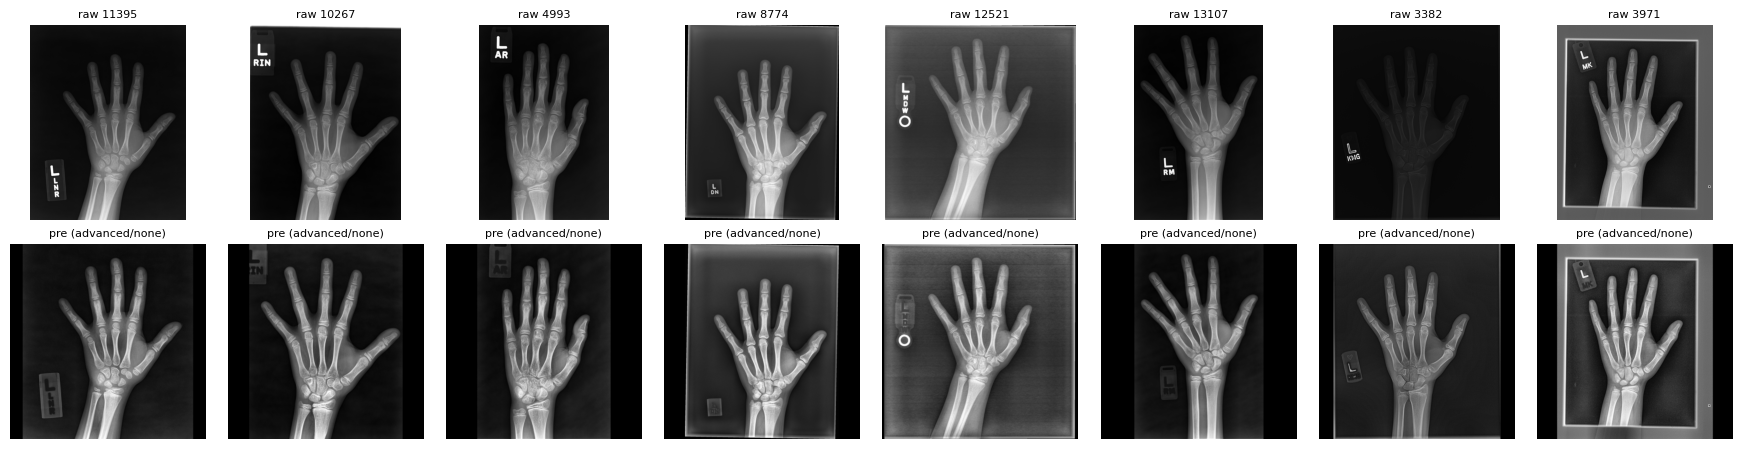

In [10]:
N_QC = 8          # 확인할 장수 (24~48 권장, 여러 번 실행하며 seed만 바꿔도 됨)
QC_SEED = SEED

sample = train_df.sample(N_QC, random_state=QC_SEED)
cols = min(8, N_QC); rows = int(np.ceil(N_QC / cols))
fig, axes = plt.subplots(rows*2, cols, figsize=(2.2*cols, 4.6*rows))
axes = np.atleast_2d(axes)
for j, (_, r) in enumerate(sample.iterrows()):
    rr, cc = (j // cols) * 2, j % cols
    raw = imread_kr(r["path"], cv2.IMREAD_GRAYSCALE)
    pre = imread_kr(CACHE_DIR/"train"/f"{r['id']}.png", cv2.IMREAD_GRAYSCALE)
    axes[rr,   cc].imshow(raw, cmap="gray"); axes[rr,   cc].set_title(f"raw {r['id']}", fontsize=8)
    axes[rr+1, cc].imshow(pre, cmap="gray"); axes[rr+1, cc].set_title(f"pre ({CROP_MODE}/{EQUALIZE})", fontsize=8)
for ax in axes.ravel(): ax.axis("off")
plt.tight_layout(); plt.show()


---
# PART 2 · 학습 설정 ⚙️  *(하이퍼파라미터를 여기서 바꾸고, 이 파트부터 아래로 재실행)*

In [11]:
# ── 하이퍼파라미터 (여기만 바꿔 재실험) ───────────────────────────────
BATCH_SIZE     = 16       # OOM 시 8
EPOCHS         = 100      # 넉넉히 — 조기종료가 알아서 멈춤
LR             = 1e-4
WEIGHT_DECAY   = 1e-5
FREEZE_BACKBONE= False    # 미세조정(False)=최고성능 / 동결(True)=빠름·안정
BILINEAR_NORM  = False    # 논문 생략(≤0.02개월). 학습 불안정 시 True
GENDER_EMB_DIM = 16
REDUCE_1, REDUCE_2 = 512, 128
NUM_WORKERS    = 0        # Windows+Jupyter 안전값(.py에선 4+ 권장)
USE_AMP        = True     # bilinear 구간은 내부에서 fp32로 강제되므로 안전
RESUME         = False    # last.pt에서 이어서 학습하려면 True
EARLY_STOP_PATIENCE = 15  # 검증 MAE가 이 에폭 수만큼 개선 없으면 조기종료(<0이면 끔)
MIN_DELTA           = 0.01# 개선으로 인정할 최소 MAE 감소(개월)
# ──────────────────────────────────────────────────────────────────
# 참고) 타깃은 학습셋 통계로 z-정규화 후 L1 학습(논문 미명시 · 수렴 안정화용 가정).
#       평가·저장·추론은 모두 개월 단위로 환산되므로 MAE 해석은 논문과 동일합니다.

ARCH = {"REDUCE_1": REDUCE_1, "REDUCE_2": REDUCE_2, "GENDER_EMB_DIM": GENDER_EMB_DIM,
        "BILINEAR_NORM": BILINEAR_NORM, "IMG_SIZE": IMG_SIZE,
        "CROP_MODE": CROP_MODE, "USE_AUG": USE_AUG, "EQUALIZE": EQUALIZE}
print("설정:", ARCH)
print(f"batch {BATCH_SIZE} | epochs {EPOCHS} | lr {LR} | resume {RESUME}")


설정: {'REDUCE_1': 512, 'REDUCE_2': 128, 'GENDER_EMB_DIM': 16, 'BILINEAR_NORM': False, 'IMG_SIZE': 512, 'CROP_MODE': 'advanced', 'USE_AUG': False, 'EQUALIZE': 'none'}
batch 16 | epochs 100 | lr 0.0001 | resume False


In [12]:
# 데이터로더
train_loader = DataLoader(BoneAgeDataset(train_df, "train", train_tf),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(BoneAgeDataset(val_df, "val", eval_tf),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(BoneAgeDataset(test_df, "test", eval_tf),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True) if len(test_df) else None
print("배치 수: train", len(train_loader), "| val", len(val_loader),
      "| test", (len(test_loader) if test_loader else 0))

배치 수: train 787 | val 90 | test 13


In [13]:
# 모델·옵티마이저·스케줄러 (RESUME이면 last.pt에서 복원)
model     = build_model(ARCH, pretrained=True, freeze=FREEZE_BACKBONE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, "min", factor=0.5, patience=3)
scaler    = torch.amp.GradScaler("cuda", enabled=USE_AMP)

if RESUME and LAST_CKPT.exists():
    ck = torch.load(LAST_CKPT, map_location=device)
    model.load_state_dict(ck["model"]); optimizer.load_state_dict(ck["optimizer"])
    scheduler.load_state_dict(ck["scheduler"]); scaler.load_state_dict(ck["scaler"])
    start_epoch = ck["epoch"] + 1; best_val = ck["best_val"]; history = ck["history"]
    epochs_no_improve = ck.get("no_improve", 0)
    print(f"🔄 재개: epoch {start_epoch}부터 · best_val {best_val:.2f} · 개선정체 {epochs_no_improve}")
else:
    start_epoch, best_val, epochs_no_improve = 1, float("inf"), 0
    history = {"train_mae": [], "val_mae": []}
    print("🆕 새로 학습 시작")

n_params = sum(p.numel() for p in model.parameters())/1e6
print(f"파라미터 {n_params:.1f}M (논문 ≈23.9M)")

C:\Project\PythonProject\PyTorch001\.venv\Lib\site-packages\torchvision\models\feature_extraction.py:175: UserWarning: NOTE: The nodes obtained by tracing the model in eval mode are a subsequence of those obtained in train mode. When choosing nodes for feature extraction, you may need to specify output nodes for train and eval mode separately.
  warnings.warn(msg + suggestion_msg)


🆕 새로 학습 시작
파라미터 22.9M (논문 ≈23.9M)


---
# PART 3 · 학습  *(best 즉시 저장 · 조기 종료 · 중단 재개)*
- best.pt: 검증 MAE 최저 순간 저장 → PART 4가 이걸 로드
- last.pt: 매 에폭 저장(조기종료 카운터 포함) → `RESUME=True`로 재개
- **조기 종료**: 검증 MAE가 `EARLY_STOP_PATIENCE` 에폭 연속 `MIN_DELTA` 이상 개선되지 않으면 자동 중단(스케줄러가 LR을 먼저 낮춘 뒤에도 정체하면 멈춤).
- Kernel 정지 버튼을 눌러도 `KeyboardInterrupt`를 잡아 last.pt를 남깁니다.

In [14]:
criterion = nn.L1Loss()
best_epoch = start_epoch - epochs_no_improve   # best가 나온 에폭(로그용)
try:
    for epoch in range(start_epoch, EPOCHS + 1):
        model.train(); run_abs, seen = 0.0, 0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch:02d}/{EPOCHS}")
        for x, g, yn, ym in pbar:
            x, g, yn = x.to(device), g.to(device), yn.to(device).squeeze(1)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=USE_AMP):
                pred = model(x, g); loss = criterion(pred, yn)
            scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
            run_abs += mae_months(pred, ym, AGE_MEAN, AGE_STD); seen += x.size(0)
            pbar.set_postfix(train_mae=f"{run_abs/seen:.2f}")

        tr_mae = run_abs / seen
        va_mae = evaluate(model, val_loader, AGE_MEAN, AGE_STD, USE_AMP)
        scheduler.step(va_mae)
        history["train_mae"].append(tr_mae); history["val_mae"].append(va_mae)

        # 개선 판정(MIN_DELTA 이상 감소해야 개선으로 인정)
        if va_mae < best_val - MIN_DELTA:
            best_val = va_mae; epochs_no_improve = 0; best_epoch = epoch
            save_checkpoint(BEST_CKPT, model, ARCH, AGE_MEAN, AGE_STD, best_val=best_val)
            flag = f"✔ best 저장 (val {best_val:.2f})"
        else:
            epochs_no_improve += 1
            flag = f"개선 없음 {epochs_no_improve}/{EARLY_STOP_PATIENCE}"
        print(f"  → train {tr_mae:.2f} · val {va_mae:.2f} · lr {optimizer.param_groups[0]['lr']:.1e} · {flag}")

        # 매 에폭 last 저장(조기종료 카운터 포함) + history 저장
        save_checkpoint(LAST_CKPT, model, ARCH, AGE_MEAN, AGE_STD,
                        optimizer, scheduler, scaler, epoch, best_val, history,
                        no_improve=epochs_no_improve)
        json.dump(history, open(HISTORY_JSON, "w"))

        # 조기 종료 (EARLY_STOP_PATIENCE < 0 이면 비활성)
        if EARLY_STOP_PATIENCE >= 0 and epochs_no_improve >= EARLY_STOP_PATIENCE:
            print(f"\n⏹ 조기 종료: {EARLY_STOP_PATIENCE}에폭 연속 개선 없음 "
                  f"· 최고 MAE {best_val:.2f} @ epoch {best_epoch}")
            break
    else:
        print(f"\n🏁 정상 종료(전체 {EPOCHS}에폭) · 최고 검증 MAE {best_val:.2f} @ epoch {best_epoch} (논문 목표 4.10)")
except KeyboardInterrupt:
    save_checkpoint(LAST_CKPT, model, ARCH, AGE_MEAN, AGE_STD,
                    optimizer, scheduler, scaler, epoch, best_val, history,
                    no_improve=epochs_no_improve)
    json.dump(history, open(HISTORY_JSON, "w"))
    print(f"\n⏸ 중단 감지 — last.pt 저장(epoch {epoch}). PART 2에서 RESUME=True로 재개하세요.")

Epoch 01/100:   0%|          | 0/787 [00:00<?, ?it/s]

  → train 14.18 · val 9.49 · lr 1.0e-04 · ✔ best 저장 (val 9.49)


Epoch 02/100:   0%|          | 0/787 [00:00<?, ?it/s]

  → train 9.60 · val 9.14 · lr 1.0e-04 · ✔ best 저장 (val 9.14)


Epoch 03/100:   0%|          | 0/787 [00:00<?, ?it/s]

...

  → train 0.47 · val 6.99 · lr 1.6e-06 · 개선 없음 13/15


Epoch 54/100:   0%|          | 0/787 [00:00<?, ?it/s]

  → train 0.45 · val 7.00 · lr 1.6e-06 · 개선 없음 14/15


Epoch 55/100:   0%|          | 0/787 [00:00<?, ?it/s]

  → train 0.46 · val 7.00 · lr 1.6e-06 · 개선 없음 15/15

⏹ 조기 종료: 15에폭 연속 개선 없음 · 최고 MAE 7.00 @ epoch 40


---
# PART 4 · 평가·설명·추론  *(학습 없이 저장된 best.pt만 로드 — 다른 사람도 이 파트만 실행 가능)*
> 이 셀을 먼저 실행하면 `eval_model`이 준비됩니다. 단일 이미지 추론(맨 아래)은 `best.pt`+이미지 1장이면 됩니다.

In [15]:
assert BEST_CKPT.exists(), "best.pt 없음 — PART 3을 먼저 실행하거나 체크포인트를 받아 checkpoints/에 두세요."
ck = torch.load(BEST_CKPT, map_location=device)
eval_model = build_model(ck["arch"], pretrained=False)
eval_model.load_state_dict(ck["model"]); eval_model.eval()
EM_MEAN, EM_STD, EM_IMG = ck["age_mean"], ck["age_std"], ck["arch"]["IMG_SIZE"]
print(f"✅ best.pt 로드 완료 · 정규화 {EM_MEAN:.1f}±{EM_STD:.1f} · IMG {EM_IMG}")

C:\Project\PythonProject\PyTorch001\.venv\Lib\site-packages\torchvision\models\inception.py:43: FutureWarning: The default weight initialization of inception_v3 will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


✅ best.pt 로드 완료 · 정규화 127.3±41.2 · IMG 512


C:\Project\PythonProject\PyTorch001\.venv\Lib\site-packages\torchvision\models\feature_extraction.py:175: UserWarning: NOTE: The nodes obtained by tracing the model in eval mode are a subsequence of those obtained in train mode. When choosing nodes for feature extraction, you may need to specify output nodes for train and eval mode separately.
  warnings.warn(msg + suggestion_msg)


### 4-1. 학습 곡선 (history.json 로드 · 논문 그림 8)

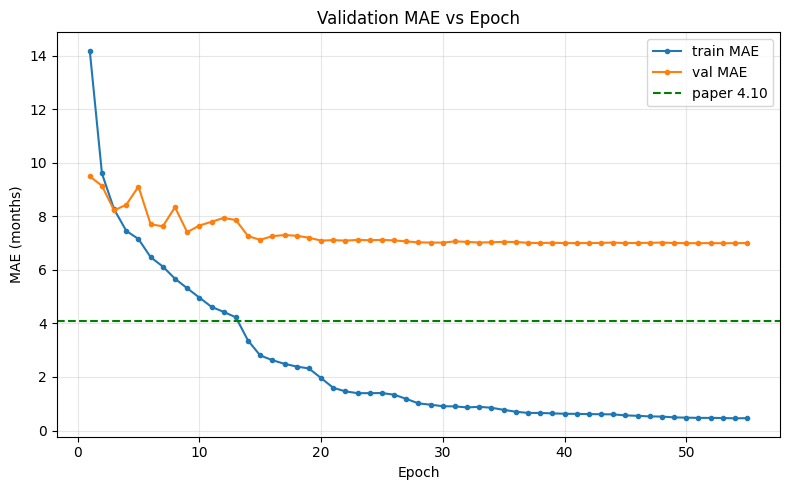

In [16]:
hist = json.load(open(HISTORY_JSON)) if HISTORY_JSON.exists() else history
ep = range(1, len(hist["train_mae"]) + 1)
plt.figure(figsize=(8, 5))
plt.plot(ep, hist["train_mae"], "-o", ms=3, label="train MAE")
plt.plot(ep, hist["val_mae"],   "-o", ms=3, label="val MAE")
plt.axhline(4.10, ls="--", c="green", label="paper 4.10")
plt.xlabel("Epoch"); plt.ylabel("MAE (months)"); plt.title("Validation MAE vs Epoch")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

### 4-2. 검증셋 예측 · 산점도 · 연령대별 MAE (논문 표 6)

predict:   0%|          | 0/90 [00:00<?, ?it/s]

전체 검증 MAE 7.00 · RMSE 9.44 개월 · 편향 -0.22


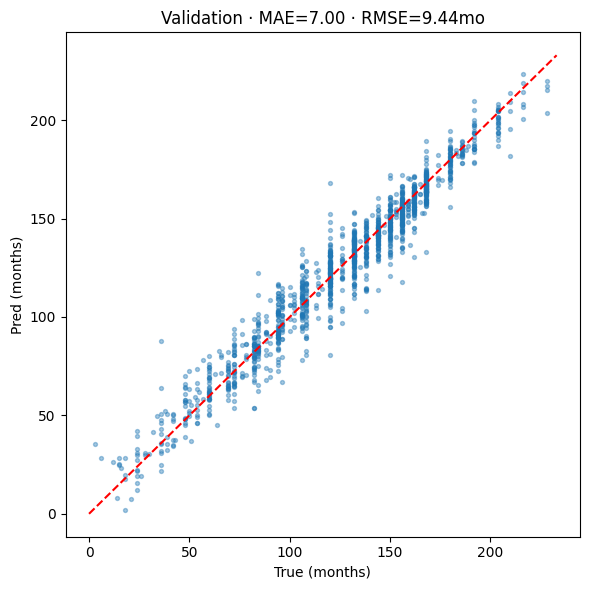

  group |    N |   MAE |   bias
   0-4y |   56 |  9.57 |  +4.48
   4-8y |  286 |  7.87 |  +2.25
  8-12y |  464 |  7.87 |  +0.74
 12-16y |  557 |  5.57 |  -2.36
   >16y |   62 |  7.00 |  -3.93


In [17]:
# PART 2를 안 돌렸어도 독립 실행되도록 val_loader를 여기서 구성
_val_loader = DataLoader(BoneAgeDataset(val_df, "val", eval_tf),
    batch_size=16, shuffle=False, num_workers=0, pin_memory=True)

preds, trues = [], []
with torch.no_grad():
    for x, g, yn, ym in tqdm(_val_loader, desc="predict"):
        x, g = x.to(device), g.to(device)
        with torch.amp.autocast("cuda", enabled=True):
            p = eval_model(x, g)
        preds.append(p.cpu()*EM_STD + EM_MEAN); trues.append(ym.squeeze(1))
preds = torch.cat(preds).numpy(); trues = torch.cat(trues).numpy()

overall = np.abs(preds - trues).mean()
val_rmse = np.sqrt(np.mean((preds - trues)**2))
print(f"전체 검증 MAE {overall:.2f} · RMSE {val_rmse:.2f} 개월 · 편향 {np.mean(preds-trues):+.2f}")

plt.figure(figsize=(6, 6)); plt.scatter(trues, preds, s=8, alpha=.4)
lim = [0, max(trues.max(), preds.max())+5]; plt.plot(lim, lim, "r--")
plt.xlabel("True (months)"); plt.ylabel("Pred (months)")
plt.title(f"Validation · MAE={overall:.2f} · RMSE={val_rmse:.2f}mo"); plt.tight_layout(); plt.show()

bins, labels = [0,48,96,144,192,10**5], ["0-4y","4-8y","8-12y","12-16y",">16y"]
print(f"{'group':>7} | {'N':>4} | {'MAE':>5} | {'bias':>6}")
for lo, hi, lab in zip(bins[:-1], bins[1:], labels):
    m = (trues>=lo) & (trues<hi)
    if m.sum(): print(f"{lab:>7} | {m.sum():>4} | {np.abs(preds[m]-trues[m]).mean():>5.2f} | {np.mean(preds[m]-trues[m]):>+6.2f}")

### 4-3. 최종 테스트셋 평가 — MAE / RMSE (train→학습 · val→검증 · test→최종 테스트)

학습에 전혀 쓰지 않은 **test 세트**로 최종 성능을 측정합니다. `best.pt`(검증 MAE 최저 순간)를 로드해 평가하며, 전체 **MAE·RMSE**와 연령대별 표를 함께 출력합니다.

test:   0%|          | 0/13 [00:00<?, ?it/s]

  TEST  MAE  =  5.60 개월
  TEST  RMSE =  7.04 개월
  TEST  bias = +0.35 개월   (N=200)


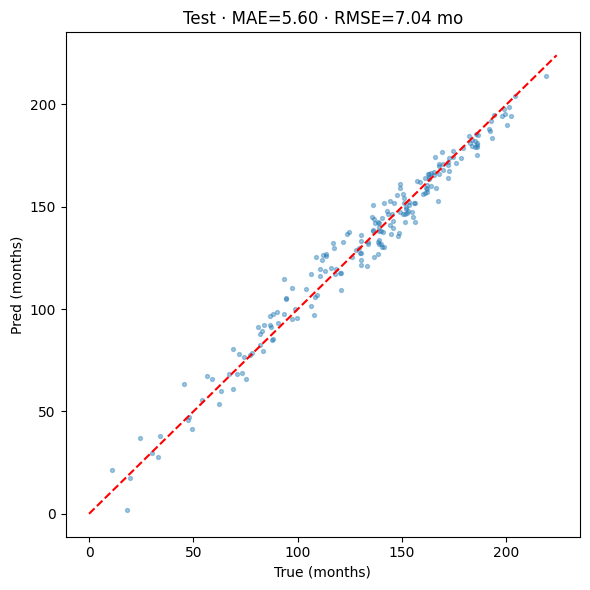

  group |    N |   MAE |  RMSE |   bias
   0-4y |   10 |  7.04 |  9.36 |  +1.77
   4-8y |   34 |  6.31 |  7.61 |  +3.16
  8-12y |   65 |  6.64 |  8.09 |  +1.84
 12-16y |   80 |  4.48 |  5.58 |  -1.65
   >16y |   11 |  4.09 |  5.35 |  -3.88


In [18]:
# 최종 테스트: train=학습 / val=검증(best 선택) / test=최종 평가. eval_model = best.pt (셀 4-0에서 로드)
assert test_loader is not None and len(test_df), \
    "test 세트가 없습니다 — 셀 0-3의 TEST_IMG_DIR / TEST_CSV 경로를 확인하고 PART 1을 다시 실행하세요."

t_preds, t_trues = [], []
with torch.no_grad():
    for x, g, yn, ym in tqdm(test_loader, desc="test"):
        x, g = x.to(device), g.to(device)
        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            p = eval_model(x, g)
        t_preds.append(p.cpu()*EM_STD + EM_MEAN); t_trues.append(ym.squeeze(1))
t_preds = torch.cat(t_preds).numpy(); t_trues = torch.cat(t_trues).numpy()

test_mae  = np.abs(t_preds - t_trues).mean()
test_rmse = np.sqrt(np.mean((t_preds - t_trues)**2))          # ★ RMSE
test_bias = float(np.mean(t_preds - t_trues))
print("="*44)
print(f"  TEST  MAE  = {test_mae:5.2f} 개월")
print(f"  TEST  RMSE = {test_rmse:5.2f} 개월")
print(f"  TEST  bias = {test_bias:+5.2f} 개월   (N={len(t_trues)})")
print("="*44)

# 산점도 (True vs Pred)
plt.figure(figsize=(6, 6)); plt.scatter(t_trues, t_preds, s=8, alpha=.4)
lim = [0, max(t_trues.max(), t_preds.max())+5]; plt.plot(lim, lim, "r--")
plt.xlabel("True (months)"); plt.ylabel("Pred (months)")
plt.title(f"Test · MAE={test_mae:.2f} · RMSE={test_rmse:.2f} mo")
plt.tight_layout(); plt.show()

# 연령대별 MAE/RMSE
bins, labels = [0,48,96,144,192,10**5], ["0-4y","4-8y","8-12y","12-16y",">16y"]
print(f"{'group':>7} | {'N':>4} | {'MAE':>5} | {'RMSE':>5} | {'bias':>6}")
for lo, hi, lab in zip(bins[:-1], bins[1:], labels):
    m = (t_trues>=lo) & (t_trues<hi)
    if m.sum():
        mae_g  = np.abs(t_preds[m]-t_trues[m]).mean()
        rmse_g = np.sqrt(np.mean((t_preds[m]-t_trues[m])**2))
        print(f"{lab:>7} | {m.sum():>4} | {mae_g:>5.2f} | {rmse_g:>5.2f} | {np.mean(t_preds[m]-t_trues[m]):>+6.2f}")


### 4-4. Grad-CAM (논문 그림 11)

AttributeError: 'NoneType' object has no attribute 'mean'

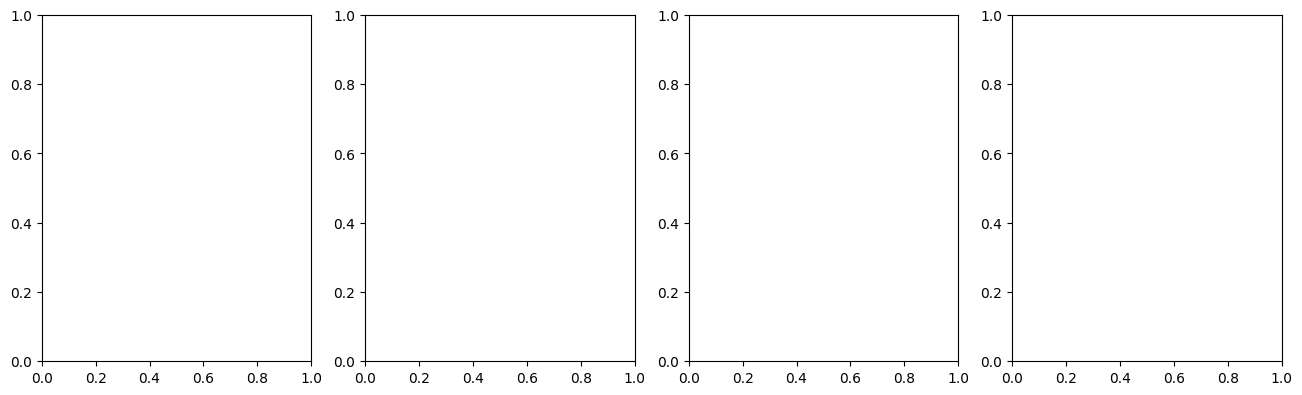

In [19]:
class GradCAM:
    '''Mixed_7c 특징 기준 Grad-CAM (회귀 출력).'''
    def __init__(self, model):
        self.model = model; self.feat = self.grad = None
        tgt = dict(model.backbone.named_modules())["Mixed_7c"]
        tgt.register_forward_hook(lambda m,i,o: setattr(self, "feat", o.detach()))
        tgt.register_full_backward_hook(lambda m,gi,go: setattr(self, "grad", go[0].detach()))
    def __call__(self, x, g):
        self.model.eval(); out = self.model(x, g); self.model.zero_grad(); out.sum().backward()
        w = self.grad.mean(dim=(2,3), keepdim=True)
        cam = F.relu((w*self.feat).sum(1))[0]
        cam = (cam-cam.min())/(cam.max()-cam.min()+1e-8)
        return cam.cpu().numpy(), out.item()

cam_engine = GradCAM(eval_model)
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
for ax, (_, r) in zip(axes, val_df.sample(4, random_state=1).iterrows()):
    g = imread_kr(CACHE_DIR/"val"/f"{r['id']}.png", cv2.IMREAD_GRAYSCALE)
    x = eval_tf(np.stack([g]*3, -1)).unsqueeze(0).to(device)
    gd = torch.tensor([[r["male"]]], dtype=torch.float32, device=device)
    cam, pn = cam_engine(x, gd); pred_month = pn*EM_STD + EM_MEAN
    heat = cv2.applyColorMap(np.uint8(255*cv2.resize(cam,(EM_IMG,EM_IMG))), cv2.COLORMAP_JET)
    over = cv2.addWeighted(cv2.cvtColor(g, cv2.COLOR_GRAY2BGR), 0.55, heat, 0.45, 0)
    ax.imshow(cv2.cvtColor(over, cv2.COLOR_BGR2RGB))
    ax.set_title(f"pred {pred_month:.0f}/true {int(r.boneage)}mo"); ax.axis("off")
plt.tight_layout(); plt.show()

### 4-5. 단일 이미지 추론 (완전 독립 — best.pt + 이미지 1장이면 끝)
다른 사람은 `best.pt`만 받아 `checkpoints/`에 두고, PART 0 실행 후 이 함수만 호출하면 됩니다.

In [ ]:
def predict_bone_age(image_path, is_male, ckpt_path=BEST_CKPT):
    """원본 X-ray 경로 + 성별(True=남) -> 골연령(개월).
       전처리(해상도·크롭모드)·모델·정규화상수를 모두 체크포인트에서 읽어 자체 완결."""
    ck = torch.load(ckpt_path, map_location=device)
    m = build_model(ck["arch"], pretrained=False); m.load_state_dict(ck["model"]); m.eval()
    g = imread_kr(image_path, cv2.IMREAD_GRAYSCALE)
    if g is None: raise FileNotFoundError(image_path)
    pre = preprocess(g, size=ck["arch"]["IMG_SIZE"],
                     mode=ck["arch"].get("CROP_MODE", "paper"),
                     equalize=ck["arch"].get("EQUALIZE", "he"))   # 학습과 동일한 전처리 보장
    x  = eval_tf(np.stack([pre]*3, -1)).unsqueeze(0).to(device)
    gd = torch.tensor([[float(is_male)]], dtype=torch.float32, device=device)
    with torch.no_grad(), torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
        pn = m(x, gd).item()
    return pn * ck["age_std"] + ck["age_mean"]

# 예시:
# months = predict_bone_age(VAL_IMG_DIR / "1386.png", is_male=True)
# print(f"예측 골연령: {months:.1f} 개월")
print("추론 함수 준비 완료 · best.pt:", BEST_CKPT)
